In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install xgboost shap imbalanced-learn
print("Libraries installed ✅")

Libraries installed ✅


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import shap
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")

Libraries loaded ✅


In [9]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/predictive_maintenance/"

# Load CSVs
X_train = pd.read_csv(path + "X_train.csv").values
X_test  = pd.read_csv(path + "X_test.csv").values
y_train = pd.read_csv(path + "y_train.csv").values.ravel()
y_test  = pd.read_csv(path + "y_test.csv").values.ravel()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("Data loaded ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train: (15457, 8)
X_test: (3865, 8)
y_train: (15457,)
y_test: (3865,)
Data loaded ✅


In [12]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1933
           1       0.87      0.85      0.86      1932

    accuracy                           0.87      3865
   macro avg       0.87      0.87      0.87      3865
weighted avg       0.87      0.87      0.87      3865

ROC-AUC: 0.9365423895102925


In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1933
           1       0.95      0.95      0.95      1932

    accuracy                           0.95      3865
   macro avg       0.95      0.95      0.95      3865
weighted avg       0.95      0.95      0.95      3865

ROC-AUC: 0.9927062279960456


In [14]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1933
           1       0.96      0.97      0.97      1932

    accuracy                           0.97      3865
   macro avg       0.97      0.97      0.97      3865
weighted avg       0.97      0.97      0.97      3865

ROC-AUC: 0.9966427066564272


                 Model  ROC-AUC
2              XGBoost   0.9966
1        Random Forest   0.9927
0  Logistic Regression   0.9365


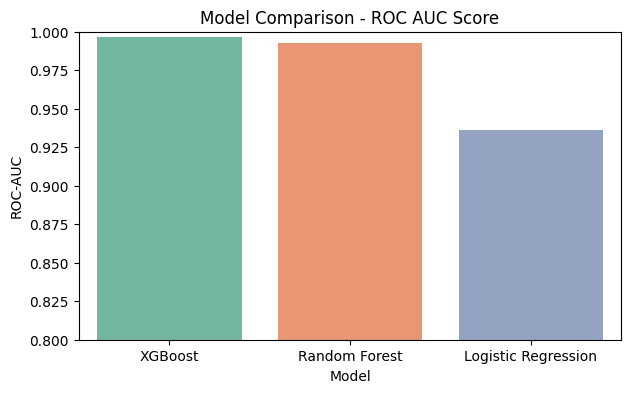

In [15]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = []
for name, model in models.items():
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]
    results.append({
        "Model": name,
        "ROC-AUC": round(roc_auc_score(y_test, proba), 4)
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
print(results_df)

plt.figure(figsize=(7,4))
sns.barplot(x="Model", y="ROC-AUC", data=results_df, palette="Set2")
plt.title("Model Comparison - ROC AUC Score")
plt.ylim(0.8, 1.0)
plt.show()

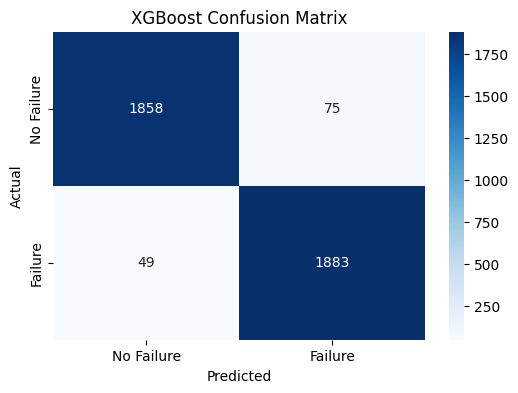

In [16]:
cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.title("XGBoost Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

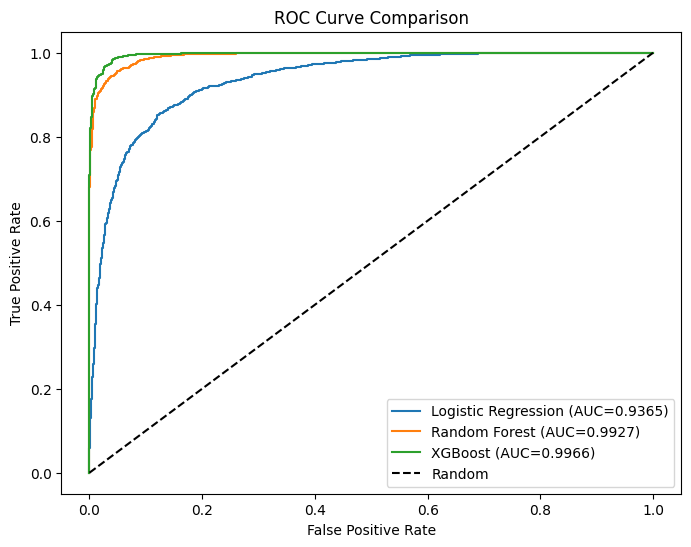

In [17]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

plt.plot([0,1], [0,1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Feature names loaded ✅
Total features: 10
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power', 'Temp_diff', 'Power', 'Temp_diff']


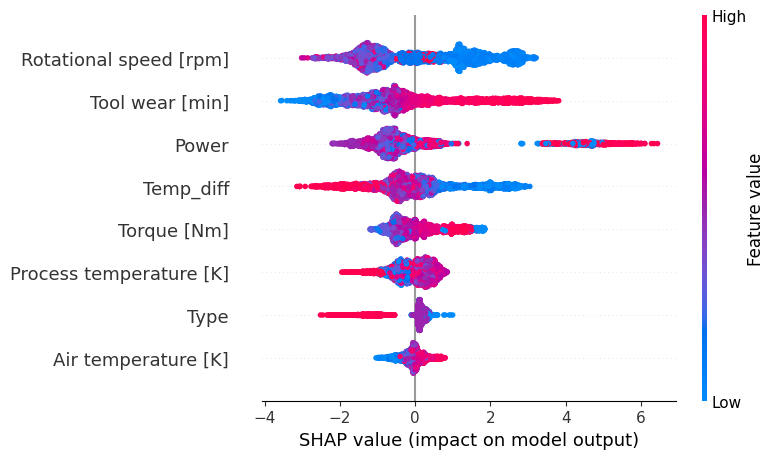

In [19]:
# Load feature names from Google Drive
path = "/content/drive/MyDrive/predictive_maintenance/"
feature_names = pd.read_csv(path + "feature_names.csv").iloc[:,0].tolist()
feature_names = feature_names + ['Power', 'Temp_diff']  # engineered features

print("Feature names loaded ✅")
print("Total features:", len(feature_names))
print(feature_names)

# SHAP values
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

In [20]:
import joblib
joblib.dump(xgb, "/content/xgb_model.pkl")
joblib.dump(rf, "/content/rf_model.pkl")
print("Models saved ✅")

Models saved ✅
